In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
import json
import random
import fiftyone as fo

import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = Path("../data/raw/OpenLogo")

for file in dataset.iterdir():
    print(file)

In [ ]:
images = list(dataset.rglob("*.jpg")) + list(dataset.rglob("*.png"))

print(len(images))

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img_path in zip(axes.ravel(), random.sample(images, 16)):
    
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

plt.show()

In [ ]:
sizes = []

for img_path in images:
    
    image = cv2.imread(str(img_path))
    h, w = image.shape[:2]
    sizes.append([w, h])

sizes = pd.DataFrame(sizes, columns=['width', 'height'])
sizes.head()

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(sizes['width'], sizes['height'], alpha=0.4)

plt.xlabel('Width')
plt.ylabel('Height')

plt.show()

In [ ]:
import pprint

samples_path = dataset / 'samples.json'

with open(samples_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
    print(type(data))
    print(data.keys())
    
    sample = data['samples'][0]
    print(sample)
    print(sample.keys())

    print(len(data['samples']))

    pprint.pprint(sample)


In [ ]:
sample = data['samples'][0]
image_path = dataset / sample['filepath']
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')

height, width = image.shape[:2]
print(width, height)

detections = sample['ground_truth']['detections']
print(detections[0])

bbox = detections[0]['bounding_box']

x = int(bbox[0] * width)
y = int(bbox[1] * height)
w = int(bbox[2] * width)
h = int(bbox[3] * height)

cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

label = detections[0]['label']

cv2.putText(image, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis('off')


Importing samples...
 100% |█████████████| 27083/27083 [856.8ms elapsed, 0s remaining, 31.6K samples/s]      


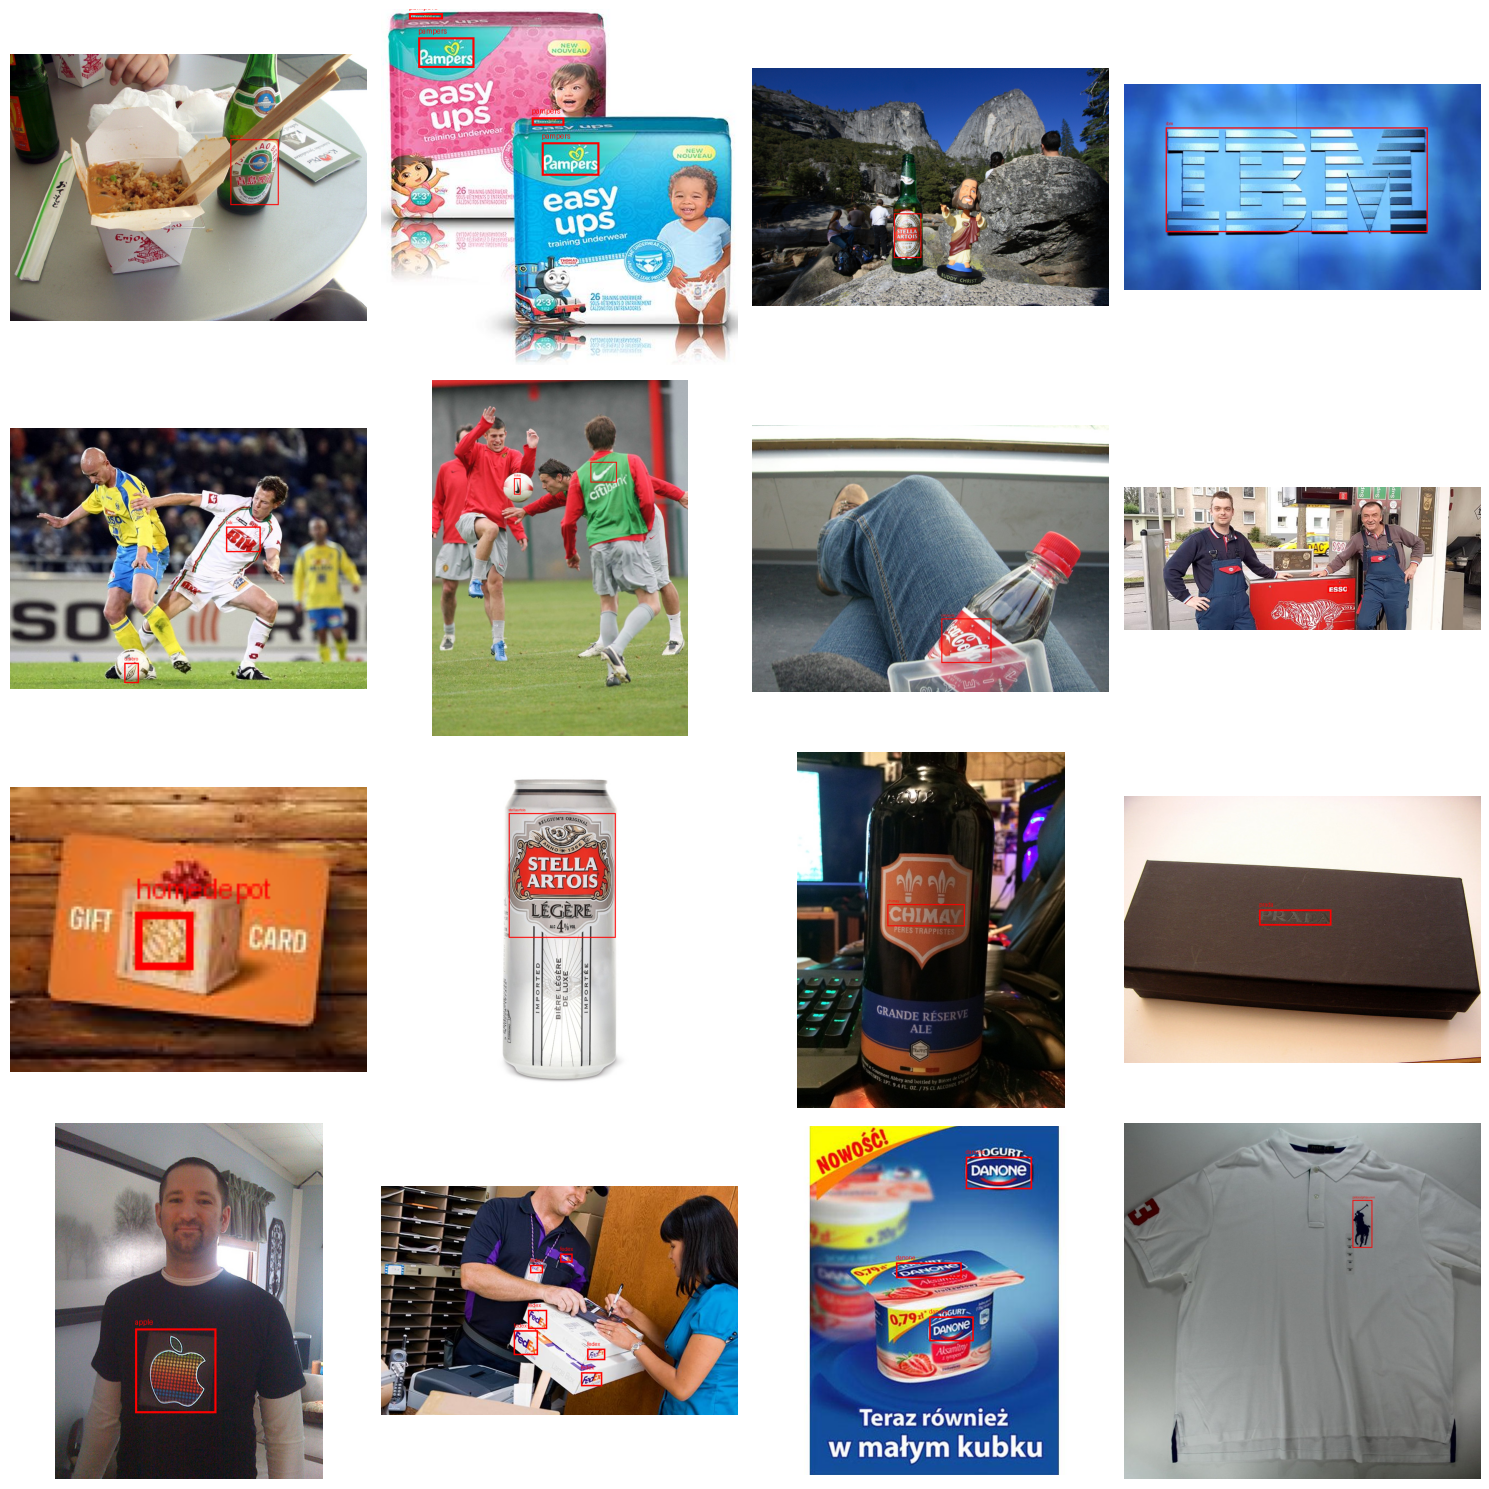

In [24]:
DATASET_DIR = Path("../data/raw/OpenLogo")

dataset = fo.Dataset.from_dir(dataset_dir=str(DATASET_DIR), dataset_type=fo.types.FiftyOneDataset)

samples = list(dataset.take(16))

fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for ax, sample in zip(axes.ravel(), samples):
    image = Image.open(sample.filepath).convert('RGB')
    draw = ImageDraw.Draw(image)

    width, height = image.size

    if sample.ground_truth:
        for det in sample.ground_truth.detections:
            x, y, w, h = det.bounding_box
            
            x1 = int(x * width)
            y1 = int(y * height)
            x2 = int((x + w) * width)
            y2 = int((y + h) * height)

            draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
            draw.text((x1, y1 - 15), det.label, fill='red')
        
    ax.imshow(image)
    ax.axis('off')

plt.tight_layout()
plt.show()
